# 00 · Data Overview

Notebook base para entender el dataset, revisar la variable objetivo y dejar documentadas decisiones descriptivas antes del modelado.


## Objetivos

- Revisar calidad y cobertura de datos.
- Inspeccionar la distribución de `precio_m2` y definir un filtro analítico razonable.
- Explorar patrones espaciales iniciales del target.
- Detectar variables candidatas y posibles sesgos del dataset.
- Dejar una base clara para los notebooks de modelado y análisis espacial.


In [55]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "00_data_overview"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


PosixPath('/home/saneliges/Escritorio/caba-property-opportunities')

## Carga de datos

Se cargan los datos procesados de `data/processed`: alquiler (`arg_alquiler_data_processed.csv`) y venta (`arg_venta_data_processed.csv`). El análisis principal sigue enfocado en venta, pero ahora admite un `subset_config` para trabajar con una muestra o filtros específicos sin tocar el resto del notebook.

El subconjunto permite, por ejemplo:
- muestrear filas (`sample_n` o `sample_frac`),
- filtrar por barrios,
- restringir a `split` específicos,
- quedarse solo con publicaciones activas,
- exigir un mínimo de `area_m2_total`.


In [56]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"
rental_path = DATA_DIR / "arg_alquiler_data_processed.csv"
sale_path = DATA_DIR / "arg_venta_data_processed.csv"

with pd.option_context("display.max_columns", 200):
    df_rental = pd.read_csv(rental_path)
    df_sale = pd.read_csv(sale_path)

for dataset in (df_rental, df_sale):
    dataset["precio_sobre_m2"] = dataset["precio"] / dataset["area_m2_total"]

subset_config = {
    "sample_n": 5000,
    "sample_frac": None,
    "random_state": 42,
    "barrios": None,
    "splits": None,
    "active_only": False,
    "min_area_m2": None,
}

def build_sale_subset(df_source, config):
    subset = df_source.copy()
    applied_filters = []
    barrio_col = "barrio_right" if "barrio_right" in subset.columns else "barrio"

    if config["active_only"]:
        subset = subset.loc[subset["valido_hasta"].isna()].copy()
        applied_filters.append("solo publicaciones activas")

    if config["barrios"]:
        subset = subset.loc[subset[barrio_col].isin(config["barrios"])].copy()
        applied_filters.append(f"barrios={config['barrios']}")

    if config["splits"]:
        subset = subset.loc[subset["split"].isin(config["splits"])].copy()
        applied_filters.append(f"splits={config['splits']}")

    if config["min_area_m2"] is not None:
        subset = subset.loc[subset["area_m2_total"] >= config["min_area_m2"]].copy()
        applied_filters.append(f"area_m2_total>={config['min_area_m2']}")

    if config["sample_frac"] is not None:
        subset = subset.sample(
            frac=config["sample_frac"],
            random_state=config["random_state"],
        )
        applied_filters.append(f"sample_frac={config['sample_frac']}")
    elif config["sample_n"] is not None and len(subset) > int(config["sample_n"]):
        subset = subset.sample(
            n=int(config["sample_n"]),
            random_state=config["random_state"],
        )
        applied_filters.append(f"sample_n={int(config['sample_n'])}")

    subset = subset.reset_index(drop=True)

    if subset.empty:
        raise ValueError("El subconjunto quedó vacío. Ajustá subset_config.")

    return subset, applied_filters

# Dataset principal para análisis de venta.
df, subset_filters = build_sale_subset(df_sale, subset_config)
if "barrio" not in df.columns and "barrio_right" in df.columns:
    df["barrio"] = df["barrio_right"]
analysis_scope = "subconjunto configurado" if subset_filters else "dataset completo"
target_col = "precio_sobre_m2"
coord_cols = ["longitud", "latitud"]
id_col = "id" if "id" in df.columns else "id_left"

print("Dataset de alquileres (completo):", df_rental.shape)
print("Dataset de venta (completo):", df_sale.shape)
print(f"Dataset principal ({analysis_scope}):", df.shape)
print(f"Cobertura del subconjunto sobre venta: {len(df) / len(df_sale):.1%}")
if subset_filters:
    print("Filtros aplicados al dataset principal:")
    for step in subset_filters:
        print("-", step)
else:
    print("No se aplicaron filtros; el dataset principal usa todas las filas de venta.")
print("Columnas comunes entre ambos datasets:")
print(sorted(set(df_rental.columns) & set(df_sale.columns)))

print("Primeras filas del dataset principal:")
display(df.head(3))


Dataset de alquileres (completo): (3159, 95)
Dataset de venta (completo): (73613, 100)
Dataset principal (subconjunto configurado): (5000, 101)
Cobertura del subconjunto sobre venta: 6.8%
Filtros aplicados al dataset principal:
- sample_n=5000
Columnas comunes entre ambos datasets:
['Nombre', 'ambientes', 'ambientes_scaled', 'antiguedad', 'antiguedad_cat', 'antiguedad_scaled', 'apadrinada', 'area', 'area_m2_cubierta', 'area_m2_descubierta', 'area_m2_descubierta_scaled', 'area_m2_total', 'area_m2_total_scaled', 'area_metro', 'banos', 'banos_scaled', 'barrio_left', 'barrio_right', 'boletin_of', 'clasificac', 'cocheras', 'cocheras_scaled', 'comuna_left', 'comuna_right', 'decreto', 'disposicion', 'disposicion_Contrafrente', 'disposicion_Frente', 'disposicion_Interno', 'disposicion_Lateral', 'dist_areas_programaticas', 'dist_areas_programaticas_scaled', 'dist_avenida_rivadavia', 'dist_avenida_rivadavia_scaled', 'dist_espacio_verde', 'dist_espacio_verde_scaled', 'dist_est_educativo', 'dist_e

,idx,id_left,url,precio,moneda,expensas,tipo_unidad,area_m2_cubierta,area_m2_descubierta,area_m2_total,antiguedad,estado_edificio,ambientes,banos,estado,disposicion,orientacion,latitud,longitud,image_url,imagen_path,valido_desde,valido_hasta,cocheras,dormitorios,informacion_adicional,pozo,fecha_publicacion_aviso_dt,fecha_modificacion_aviso_dt,fecha_modificacion_puntos_dt,id_right,objeto,barrio_left,comuna_left,perimetro_,area_metro,antiguedad_cat,dist_subte,nearest_subte,dist_universidad,nearest_universidad,dist_hospital,nearest_hospital,dist_est_educativo,nearest_est_educativo,id_left.1,nombre_left,nom_mapa,barrio_right,comuna_right,ubicacion,clasificac,tiene_pati,apadrinada,decreto,fecha_decr,ordenanza_,fecha_orde,boletin_of,fecha_bole,area,perimetro,observacio,dist_espacio_verde,id_right.1,nombre_right,dist_areas_programaticas,Nombre,dist_avenida_rivadavia,n_universidades_1000m,n_robos_1000m,n_ventas_1000m_90d,velocidad_ventas_1000m_90d,estado_num,disposicion_Frente,disposicion_Contrafrente,disposicion_Lateral,disposicion_Interno,log_precio,area_m2_total_scaled,area_m2_descubierta_scaled,ambientes_scaled,banos_scaled,cocheras_scaled,antiguedad_scaled,expensas_scaled,estado_num_scaled,dist_subte_scaled,dist_universidad_scaled,dist_hospital_scaled,dist_est_educativo_scaled,dist_espacio_verde_scaled,dist_areas_programaticas_scaled,dist_avenida_rivadavia_scaled,n_robos_1000m_scaled,n_universidades_1000m_scaled,n_ventas_1000m_90d_scaled,velocidad_ventas_1000m_90d_scaled,split,precio_sobre_m2,barrio
0,26288,19218100.0,https://www.argenprop.com/departamento-en-vent...,250000.0,USD,0.0,NaN,60.0,0.0,0.0,20.0,0.0,2.0,1.0,NaN,Frente,NaN,-34.559735,-58.444818,https://www.argenprop.com/static-content/00181...,NaN,2026-04-11 05:46:02.319502,2026-04-20 23:15:09.548471,0.0,1.0,NaN,0.0,NaN,b'',b'',5.0,BARRIO,Belgrano,13.0,20430.59,8060009.10,20,983.450771,Jose Hernandez,511.555473,Universidad de Belgrano,2.218961e+06,Hospital Especializado de Gastroenterologia B....,188399.657445,Establecimiento educativo CARLOS PELLEGRINI,2226,NaN,NaN,Belgrano,13,AV VIRREY VERTIZ y JOSE HERNANDEZ,PLAZOLETA,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.208709,69.659616,NaN,168.225933,6,Área Programática Hospital Dr. J. A. Fernandez,0.0,Avenida Rivadavia,7484.979607,4,157,18,0.200000,3.0,1,0,0,0,12.429220,-1.102816,-0.396052,-0.421744,-0.064945,-0.053375,-0.233498,-0.772924,-0.087307,-0.117881,-0.413979,-0.507993,0.066150,-0.327743,-0.225084,1.357064,-0.631163,-0.087421,-0.743568,-0.743568,train,inf,Belgrano
1,30521,18461075.0,https://www.argenprop.com/departamento-en-vent...,140000.0,USD,0.0,NaN,55.0,0.0,55.0,0.0,0.0,3.0,1.0,NaN,Frente,NaN,-34.646270,-58.520160,https://www.argenprop.com/static-content/57016...,NaN,2026-04-11 05:52:29.994537,2026-04-22 04:38:55.491288,0.0,2.0,NaN,0.0,NaN,b'',b'',15.0,BARRIO,Liniers,9.0,9256.93,4374419.15,0,4935.309836,San Pedrito,4932.947567,Universidad de Flores,2.229342e+06,Hospital Especializado de Gastroenterologia B....,180604.521931,Establecimiento educativo CARLOS PELLEGRINI,1142,Plaza Sarmiento,Pza. Sarmiento,Liniers,9,TUYUTI - COSQUIN - HUMAITA - EL RASTREADOR,PLAZA,SI,NO,NaN,NaN,3.952,NaN,2.234,NaN,4321.726337,901.126051,NaN,336.618411,10,Área Programática Hospital Donacion F. Santoj...,0.0,Avenida Rivadavia,996.810117,0,94,26,0.288889,3.0,1,0,0,0,11.849405,0.112684,-0.396052,0.438209,-0.064945,-0.053375,-1.143814,-0.772924,-0.087307,3.007694,4.071453,2.309151,-1.968297,0.734006,-0.225084,-0.818334,-1.150066,-0.661898,-0.609474,-0.609474,train,2545.454545,Liniers
2,90573,19374873.0,https://www.argenprop.com/departamento-en-vent...,130000.0,USD,280000.0,NaN,52.0,0.0,52.0,40.0,0.0,3.0,1.0,NaN,Frente,NaN,-34.566570,-58.472190,https://www.argenprop.com/static-content/37847...,NaN,2026-05-12 15:01:43.195002,NaN,0.0,2.0,3 AMBIENTES. TODO AL FRENTE. 52 M2. IMPECABLE....,0.0,2026-04-07T11:14:09Z,2026-04-24T10:11:53.567Z,2026-04-17T16:35:03.647Z,5.0,BARRIO,Belgrano,13.0,20430.59,8060009.10,40,1487.031332,Echeverría - Mártires Palotino

## Visualización inicial


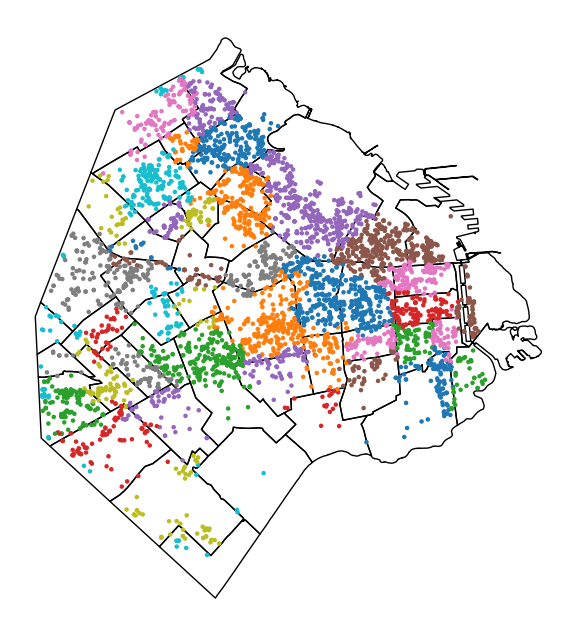

In [57]:

barrios = gpd.read_file(PROJECT_ROOT / "GeoData" / "barrios.geojson")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs='EPSG:4326'
)

barrios = barrios.to_crs(gdf.crs)

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor='black', facecolor='none')
gdf.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False,
)

ax.set_axis_off()
plt.show()



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



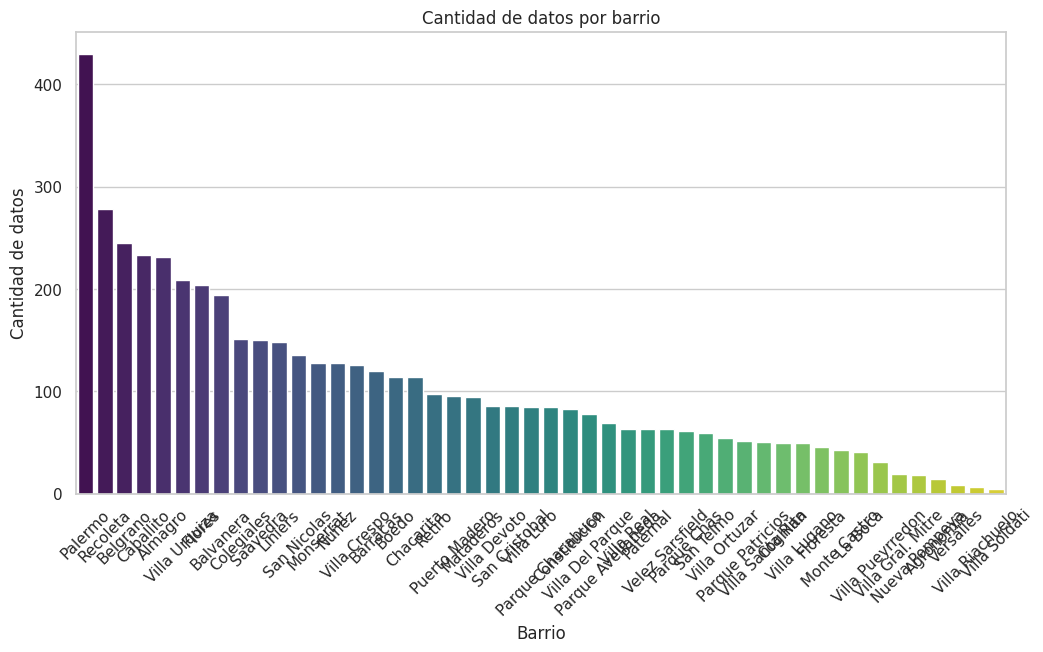

In [58]:
cant_datos_por_barrio = gdf['barrio'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=cant_datos_por_barrio.index, y=cant_datos_por_barrio.values, palette='viridis')
plt.title('Cantidad de datos por barrio')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de datos')
plt.xticks(rotation=45)
plt.show()

## Cantidad de publicaciones activas


In [59]:
proporcion_publicaciones_activas = gdf['valido_hasta'].isna().sum() / len(gdf) * 100
print(f"Proporción de publicaciones activas: {proporcion_publicaciones_activas:.2f}%")


Proporción de publicaciones activas: 40.28%


## Sanity checks iniciales


In [60]:
for name, dataset in [("Alquiler", df_rental), ("Venta completa", df_sale), ("Venta usada en el overview", df)]:
    print(f"--- {name} ---")
    print("shape:", dataset.shape)
    print("columnas:", len(dataset.columns))
    print("nulos por columna (%):")
    display((dataset.isna().mean().sort_values(ascending=False) * 100).head(20))
    print("\nTipos de datos:")
    display(dataset.dtypes.sort_index())
    print("\n")

print(f"Dataset principal para análisis inicial: venta ({analysis_scope})")
print("subset_config:", subset_config)
print("Filtros efectivos:", subset_filters if subset_filters else "ninguno")
print("Columnas objetivo y espaciales:")
print("target_col:", target_col)
print("coord_cols:", coord_cols)
print("id_col:", id_col)

print("Resumen estadístico rápido del dataset principal:")
display(df.describe(include="all").T.head(20))


--- Alquiler ---
shape: (3159, 95)
columnas: 95
nulos por columna (%):


observacio      100.000000
fecha_bole       99.525166
fecha_orde       99.525166
decreto          65.843621
fecha_decr       64.514087
orientacion      54.415954
apadrinada       46.217157
ordenanza_       45.679012
boletin_of       37.606838
valido_hasta     30.547642
estado           22.633745
nombre_left      22.443811
nom_mapa         21.937322
tipo_unidad      21.019310
ubicacion         2.817347
imagen_path       0.316556
ambientes         0.000000
antiguedad        0.000000
banos             0.000000
cocheras          0.000000
dtype: float64


Tipos de datos:


Nombre                                object
ambientes                            float64
ambientes_scaled                     float64
antiguedad                           float64
antiguedad_cat                         int64
                                      ...   
url                                   object
valido_desde                          object
valido_hasta                          object
velocidad_ventas_1000m_90d           float64
velocidad_ventas_1000m_90d_scaled    float64
Length: 95, dtype: object



--- Venta completa ---
shape: (73613, 100)
columnas: 100
nulos por columna (%):


...

observacio                    100.00
fecha_bole                     99.92
fecha_orde                     99.88
tipo_unidad                    98.78
orientacion                    98.66
estado                         98.36
imagen_path                    86.80
decreto                        65.54
fecha_decr                     63.42
fecha_publicacion_aviso_dt     53.52
ordenanza_                     49.12
apadrinada                     46.20
informacion_adicional          43.30
boletin_of                     40.84
valido_hasta                   40.28
nombre_left                    25.62
nom_mapa                       25.30
ubicacion                       2.50
image_url                       0.02
idx                             0.00
dtype: float64


Tipos de datos:


Nombre                                object
ambientes                            float64
ambientes_scaled                     float64
antiguedad                           float64
antiguedad_cat                         int64
                                      ...   
url                                   object
valido_desde                          object
valido_hasta                          object
velocidad_ventas_1000m_90d           float64
velocidad_ventas_1000m_90d_scaled    float64
Length: 101, dtype: object



Dataset principal para análisis inicial: venta (subconjunto configurado)
subset_config: {'sample_n': 5000, 'sample_frac': None, 'random_state': 42, 'barrios': None, 'splits': None, 'active_only': False, 'min_area_m2': None}
Filtros efectivos: ['sample_n=5000']
Columnas objetivo y espaciales:
target_col: precio_sobre_m2
coord_cols: ['longitud', 'latitud']
id_col: id_left
Resumen estadístico rápido del dataset principal:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idx,5000.0,NaN,NaN,NaN,47877.2536,25212.376957,4267.0,26066.75,47891.5,68614.0,93320.0
id_left,5000.0,NaN,NaN,NaN,18079851.8114,2161098.82565,1814064.0,17846590.5,18783792.0,19229978.0,19571523.0
url,5000,4672,https://www.argenprop.com/departamento-en-vent...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio,5000.0,NaN,NaN,NaN,171726.7064,136795.205174,36000.0,85900.0,129000.0,200000.0,970000.0
moneda,5000,2,USD,4990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expensas,5000.0,NaN,NaN,NaN,133703.9788,176809.909938,0.0,0.0,93000.0,190000.0,1000000.0
tipo_unidad,61,3,Departamento,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2_cubierta,5000.0,NaN,NaN,NaN,62.347956,36.36544,4.0,37.475,52.0,75.0,347.0
area_m2_descubierta,5000.0,NaN,NaN,NaN,5.235626,13.23434,0.0,0.0,0.0,5.0,171.0
area_m2_total,5000.0,NaN,NaN,NaN,50.016276,46.823472,0.0,0.0,44.0,72.0,250.0


In [61]:
df["velocidad_ventas_1000m_90d"]


0       0.200000
1       0.288889
2       1.800000
3       0.355556
4       0.255556
          ...   
4995    0.311111
4996    1.211111
4997    0.522222
4998    0.511111
4999    1.277778
Name: velocidad_ventas_1000m_90d, Length: 5000, dtype: float64

## Variable objetivo

Primero miramos el target en escala original y en escala logarítmica. Como la distribución presenta una cola derecha larga, para el resto del notebook trabajamos con un recorte analítico sobre `log1p(precio_m2)`.


Filtrado para el resto del analisis: log1p(precio_m2) < 9.2. Se conservaron 3,584 de 5,000 observaciones (71.7%).


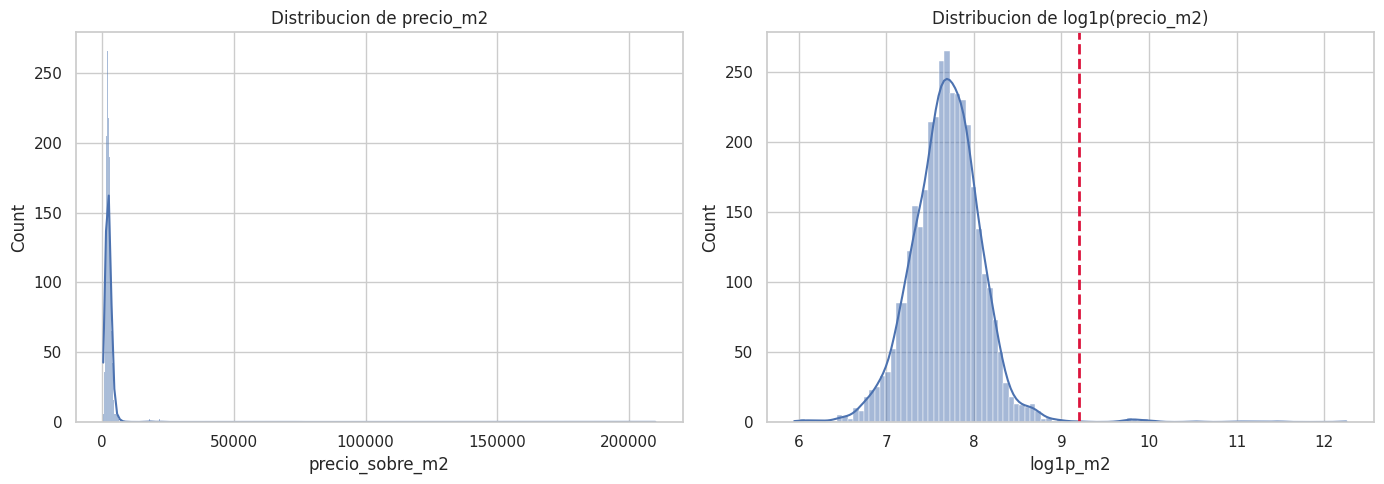

In [62]:
log1p_threshold = 9.2

df["log1p_m2"] = np.log1p(df[target_col])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title("Distribucion de precio_m2")
sns.histplot(df["log1p_m2"], kde=True, ax=axes[1])
axes[1].axvline(log1p_threshold, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("Distribucion de log1p(precio_m2)")
plt.tight_layout()

mask_log1p = np.isfinite(df["log1p_m2"]) & (df["log1p_m2"] < log1p_threshold)
n_before = len(df)
df = df.loc[mask_log1p].copy().reset_index(drop=True)

print(
    f"Filtrado para el resto del analisis: log1p(precio_m2) < {log1p_threshold}. "
    f"Se conservaron {len(df):,} de {n_before:,} observaciones ({len(df) / n_before:.1%})."
)


## Exploración espacial

Para el resto del análisis conservamos solo las observaciones con `log1p(precio_m2) < 9.2`. Luego visualizamos el target sobre el mapa de CABA para detectar gradientes espaciales gruesos y zonas con mayor dispersión aparente.


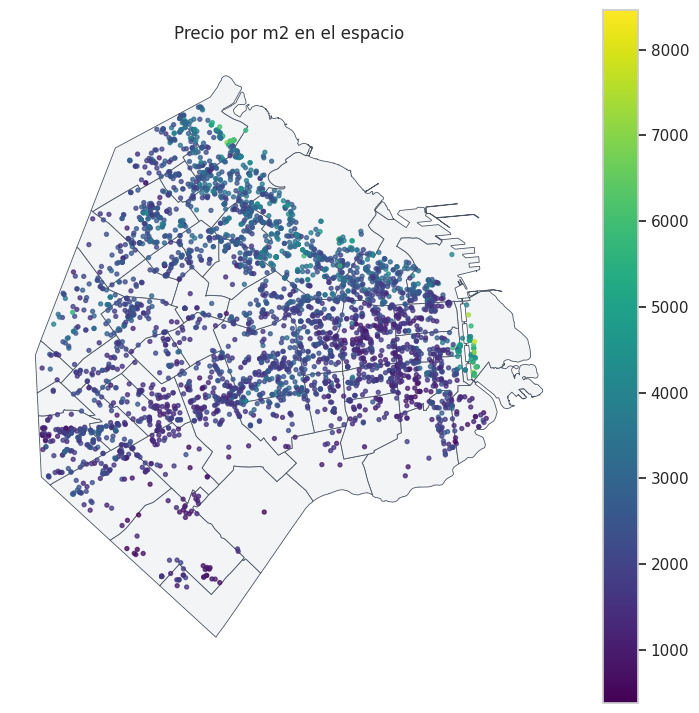

In [63]:
import geopandas as gpd
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[coord_cols[0]], df[coord_cols[1]]),
    crs="EPSG:4326",
)

barrios_plot = barrios.to_crs(gdf.crs)
fig, ax = plt.subplots(figsize=(9, 9))
barrios_plot.plot(
    ax=ax,
    edgecolor="#4b5563",
    facecolor="#f3f4f6",
    linewidth=0.6,
)
gdf.plot(
    ax=ax,
    column=target_col,
    cmap="viridis",
    alpha=0.75,
    markersize=8,
    legend=True,
)
ax.set_title("Precio por m2 en el espacio")
ax.set_axis_off()


## Correlaciones y señales candidatas

Antes de pasar al modelado conviene revisar qué variables numéricas muestran asociación lineal básica con `precio_m2`. Esta lectura es descriptiva y sirve como primer filtro de señales potencialmente útiles.


In [64]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)[target_col].sort_values(ascending=False)
display(corr.head(20))
display(corr.tail(20))

precio_sobre_m2                      1.000000
log1p_m2                             0.955648
log_precio                           0.571722
precio                               0.550764
latitud                              0.462685
perimetro_                           0.328335
dist_avenida_rivadavia               0.318929
dist_avenida_rivadavia_scaled        0.318929
area_metro                           0.274958
comuna_left                          0.251211
comuna_right                         0.249042
dist_areas_programaticas_scaled      0.232287
dist_areas_programaticas             0.232287
pozo                                 0.141324
n_ventas_1000m_90d                   0.078736
n_ventas_1000m_90d_scaled            0.078736
velocidad_ventas_1000m_90d_scaled    0.078736
velocidad_ventas_1000m_90d           0.078736
expensas                             0.078007
expensas_scaled                      0.078007
Name: precio_sobre_m2, dtype: float64

ambientes                    -0.088015
ambientes_scaled             -0.088015
area_m2_descubierta          -0.099143
area_m2_descubierta_scaled   -0.099143
dist_espacio_verde           -0.108855
dist_espacio_verde_scaled    -0.108855
dist_subte                   -0.123486
dist_subte_scaled            -0.123486
n_robos_1000m_scaled         -0.144459
n_robos_1000m                -0.144459
dist_universidad             -0.150153
dist_universidad_scaled      -0.150153
dist_hospital_scaled         -0.208192
dist_hospital                -0.208192
id_right.1                   -0.321429
antiguedad                   -0.403573
antiguedad_scaled            -0.403573
antiguedad_cat               -0.403924
estado_edificio                    NaN
observacio                         NaN
Name: precio_sobre_m2, dtype: float64

## Siguiente paso

El análisis formal de dependencia espacial se movió a [`01_spatial_dependence.ipynb`](01_spatial_dependence.ipynb), donde se desarrolla el índice de Moran, el variograma, la densidad local a escala del `range_` y la heterogeneidad barrio-superficie-precio.
